In [1]:
# Import required libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import VarianceThreshold

from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.inspection import PartialDependenceDisplay

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["MedHouseVal"] = data.target

df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
df.shape

(20640, 9)

In [4]:
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


In [5]:
target = "MedHouseVal"
print("Target Variable:", target)

Target Variable: MedHouseVal


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


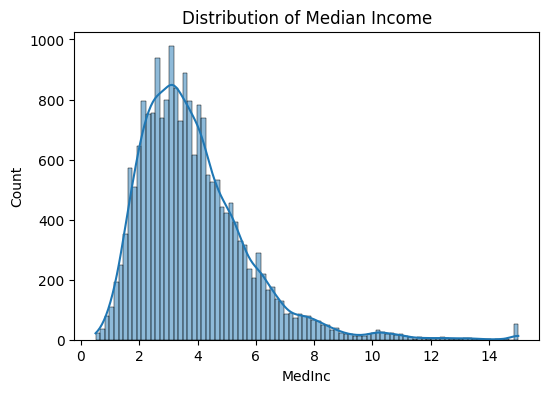

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["MedInc"], kde=True)
plt.title("Distribution of Median Income")
plt.show()

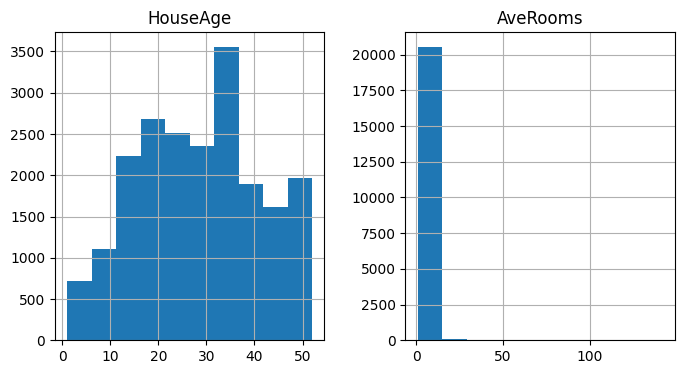

In [9]:
df[["HouseAge","AveRooms"]].hist(figsize=(8,4))
plt.show()

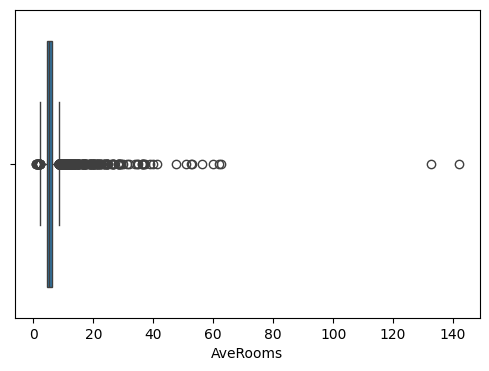

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["AveRooms"])
plt.show()

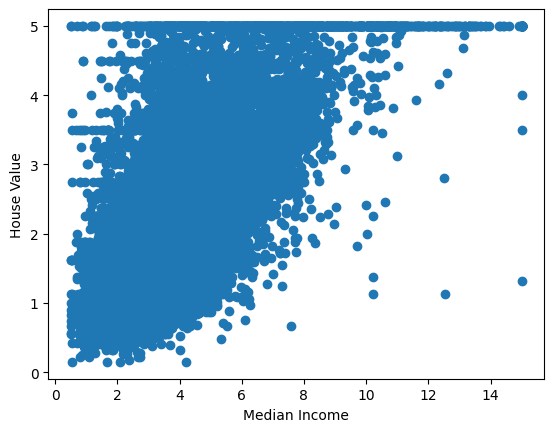

In [11]:
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.show()

In [12]:
corr = df.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


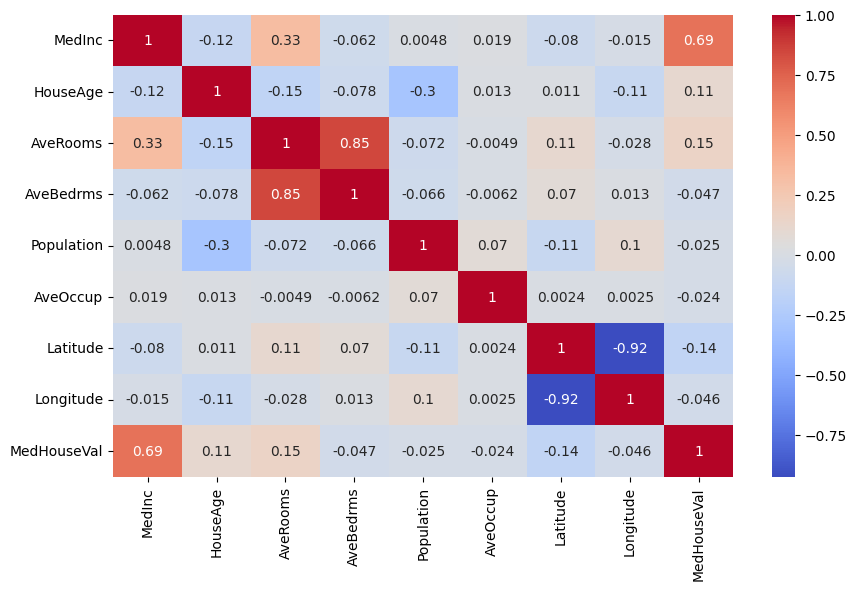

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [14]:
corr["MedHouseVal"].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


In [15]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
imputer = SimpleImputer(strategy="mean")

In [18]:
scaler = StandardScaler()

In [19]:
minmax = MinMaxScaler()

In [20]:
le = LabelEncoder()

df["AgeCategory"] = pd.cut(df["HouseAge"], bins=3, labels=["Young","Middle","Old"])
df["AgeEncoded"] = le.fit_transform(df["AgeCategory"])

In [21]:
num_features = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features)
    ]
)

In [22]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [23]:
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

In [25]:
df["RoomsPerPerson"] = df["AveRooms"] / df["Population"]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,AgeCategory,AgeEncoded,RoomsPerPerson
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,Old,1,0.021690
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,Middle,0,0.002598
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,Old,1,0.016710
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,Old,1,0.010425
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,Old,1,0.011118


In [26]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X_train)

In [27]:
selector = SelectKBest(score_func=f_regression, k=5)

X_new = selector.fit_transform(X_train, y_train)

In [28]:
vt = VarianceThreshold(threshold=0.01)

X_vt = vt.fit_transform(X_train)

In [29]:
pca = PCA(n_components=5)

X_pca = pca.fit_transform(X_train)

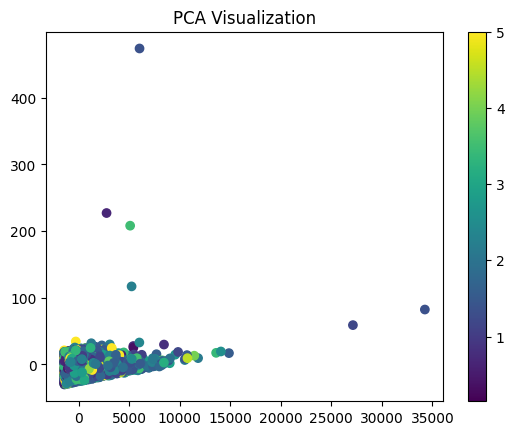

In [30]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.colorbar()
plt.title("PCA Visualization")
plt.show()

In [31]:
print("Original Shape:", X_train.shape)
print("After PCA:", X_pca.shape)

Original Shape: (16512, 8)
After PCA: (16512, 5)


In [32]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("R2:", r2_score(y_test, pred_lr))

R2: 0.5757877060324508


In [33]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("R2:", r2_score(y_test, pred_dt))

R2: 0.6192728645937278


In [34]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, pred_rf))

R2: 0.8063328365982527


In [35]:
svm = SVR()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("R2:", r2_score(y_test, pred_svm))

R2: -0.01648536010717372


In [36]:
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor())
])

model_pipeline.fit(X_train, y_train)

pred = model_pipeline.predict(X_test)

print("Pipeline R2:", r2_score(y_test, pred))

Pipeline R2: 0.8073514152481758


In [37]:
scores = cross_val_score(rf, X, y, cv=5)

print("CV Scores:", scores)
print("Average:", scores.mean())

CV Scores: [0.51277604 0.70582295 0.73864784 0.61016243 0.6830067 ]
Average: 0.6500831920904859


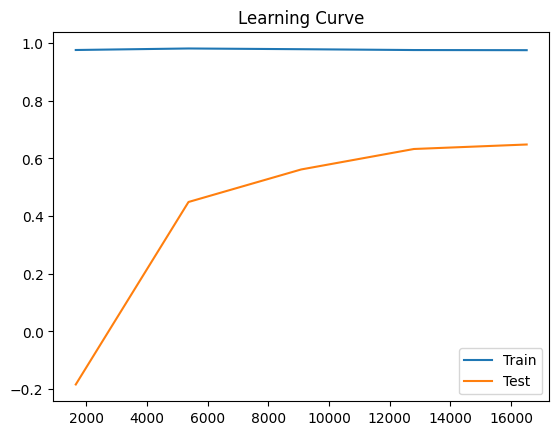

In [38]:
train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")

plt.legend()
plt.title("Learning Curve")
plt.show()

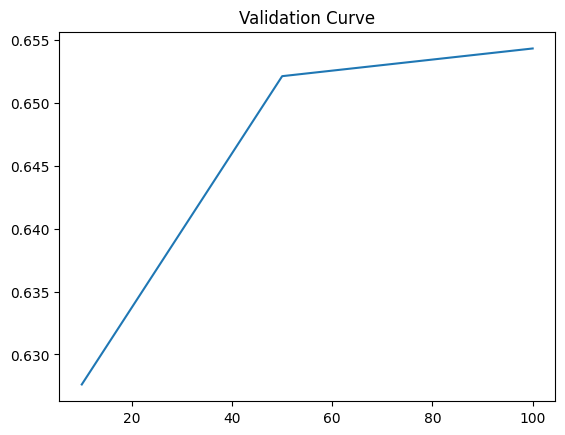

In [39]:
param_range = [10,50,100]

train_scores, test_scores = validation_curve(
    RandomForestRegressor(),
    X,
    y,
    param_name="n_estimators",
    param_range=param_range,
    cv=3
)

plt.plot(param_range, test_scores.mean(axis=1))
plt.title("Validation Curve")
plt.show()

In [40]:
param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 10, 'n_estimators': 100}

In [41]:
param_dist = {
    "n_estimators":[10,50,100,200],
    "max_depth":[None,5,10,20]
}

rand = RandomizedSearchCV(RandomForestRegressor(), param_dist, cv=3)

rand.fit(X_train, y_train)

rand.best_params_

{'n_estimators': 200, 'max_depth': None}

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

In [43]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p)

In [44]:
combined = FeatureUnion([
    ("pca", PCA(n_components=2)),
    ("select", SelectKBest(k=2))
])

combined.fit_transform(X_train, y_train)

array([[ 873.52939727,    6.72418479,    3.2596    ,   32.71      ],
       [-112.51869788,   18.26371347,    3.8125    ,   33.77      ],
       [-511.37069382,  -24.51015177,    4.1563    ,   34.66      ],
       ...,
       [ 329.52211636,    7.95161695,    2.9344    ,   34.03      ],
       [ 350.58829105,  -11.75025165,    5.7192    ,   37.58      ],
       [1192.46327198,   24.89548328,    2.5755    ,   37.77      ]])

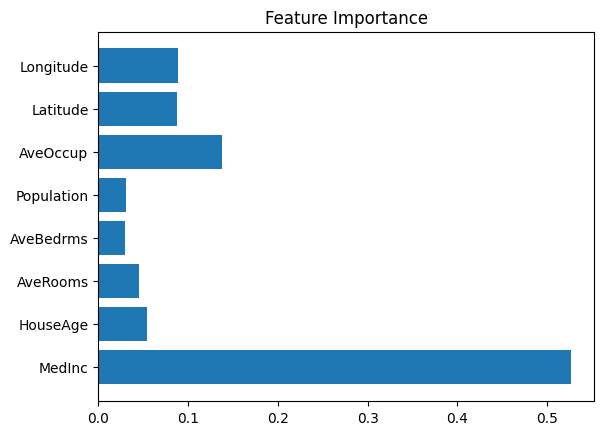

In [45]:
importances = rf.feature_importances_

features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

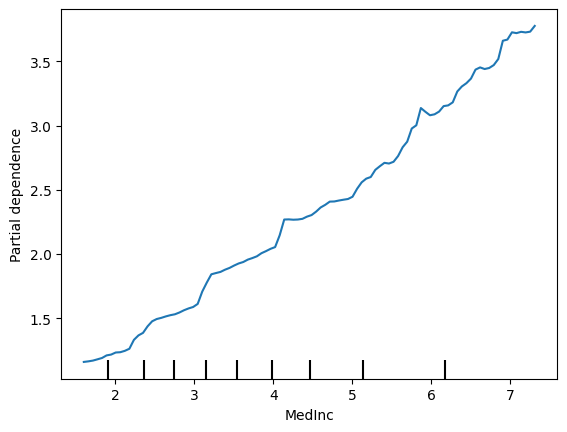

In [46]:
PartialDependenceDisplay.from_estimator(
    rf, X_train, ["MedInc"]
)

plt.show()

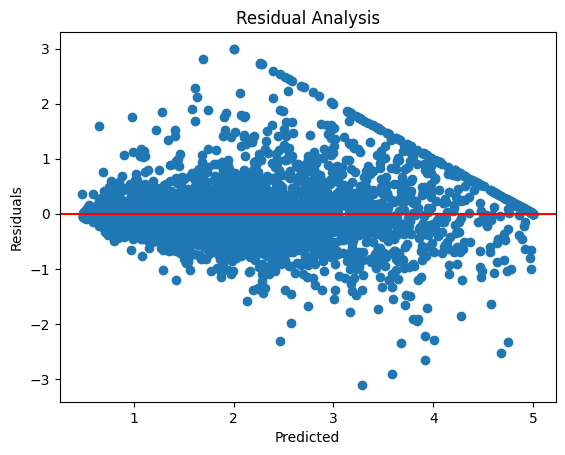

In [47]:
residuals = y_test - pred_rf

plt.scatter(pred_rf, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()